<a href="https://colab.research.google.com/github/carrisian/del-big-data-al-modelo-predictivo/blob/main/colab%5Cmodelo%20ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrenamiento de Modelos de Predicción de Calidad del Aire (Inteligencia Artificial)

Este cuaderno constituye la fase experimental más avanzada de nuestra investigación. Se desarrollan **modelos de aprendizaje profundo (Deep Learning)** basados en arquitectura **LSTM (Long Short-Term Memory)** capaces de predecir niveles de PM10 en la Región de Murcia a partir de 16 variables atmosféricas y meteorológicas.

### Metodología de Entrenamiento
Se ha implementado un sistema multiespecífico orientado a la robustez estadística:
1. **Modelos Locales:** 15 modelos independientes (uno por cada estación meteorológica) para capturar la variabilidad orográfica de cada municipio.
2. **Modelo Global:** Un modelo consolidado que integra todos los datos regionales para identificar patrones climáticos de alcance general.
3. **Validación:** Cada modelo incluye su propia curva de convergencia, permitiendo asegurar la ausencia de *overfitting* en nuestra predicción.

In [12]:
#@title 1. Configuración de Entorno y Preparación de Datos { display-mode: "form" }
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

# Montaje de Drive
if not os.path.isdir('/content/drive'):
    drive.mount('/content/drive')

PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"
RUTA_OUTPUT = os.path.join(PATH_BASE, "Modelos_IA_Listos")
os.makedirs(RUTA_OUTPUT, exist_ok=True)

# Carga de datos
df = pd.read_parquet(f"{PATH_BASE}Murcia_Dataset_Completo_Global_3H.parquet")

# Selección estricta de las variables (16 parámetros de entrada)
features = ['PM10', 'PM2.5', 'NO2', 'Ozono', 'CO', 'SO2', 'Temp', 'Hum',
            'Viento_Vel', 'Viento_Dir', 'Presion', 'Nubes', 'UV_Real',
            'UV_Cielo_Despejado', 'Lluvia', 'Radiacion']

print(f"✅ Dataset listo. Variables cargadas: {len(features)}")

✅ Dataset listo. Variables cargadas: 16



--- Iniciando modelo: Alcantarilla ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 63s 15ms/step - loss: 7.8328e-04 - val_loss: 4.5696e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5.0056e-04 - val_loss: 2.6695e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 3.9294e-04 - val_loss: 2.2769e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 3.7112e-04 - val_loss: 2.2842e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 3.5576e-04 - val_loss: 2.2227e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 3.3250e-04 - val_loss: 2.2206e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 3.2882e-04 - val_loss: 2.1656e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 3.2519e-04 - val_loss: 2.3155e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 3.2206e-04 - val_loss: 2.4574e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 3.2097e-04 - val_loss: 2.1567e-04


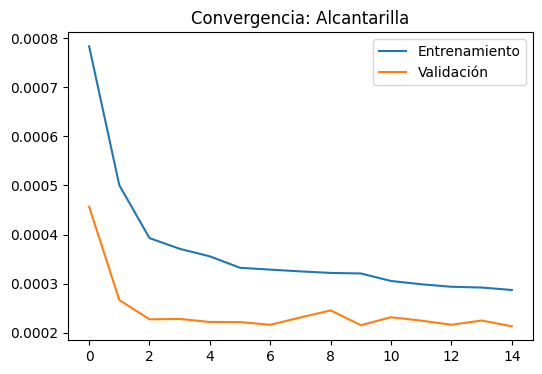

✅ Guardado: modelo_Alcantarilla.keras

--- Iniciando modelo: Archena ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 8.4980e-04 - val_loss: 4.0597e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5.3232e-04 - val_loss: 2.8337e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 4.1636e-04 - val_loss: 2.6406e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 3.6883e-04 - val_loss: 2.7198e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 3.5736e-04 - val_loss: 2.1658e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.5513e-04 - val_loss: 2.3016e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.3634e-04 - val_loss: 2.2951e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 3.3802e-04 - val_loss: 2.1024e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 3.2462e-04 - val_loss: 2.1841e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.

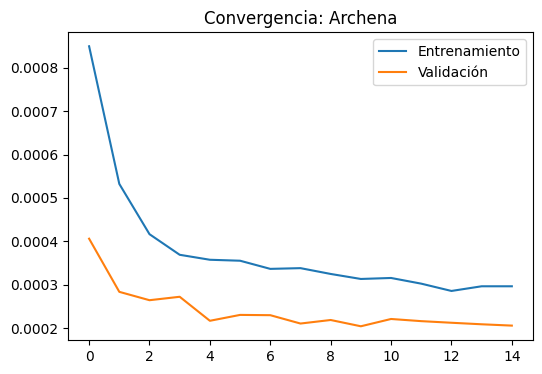

✅ Guardado: modelo_Archena.keras

--- Iniciando modelo: Caravaca de la Cruz ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 7.5204e-04 - val_loss: 3.6602e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 4.8441e-04 - val_loss: 2.4695e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.9122e-04 - val_loss: 2.2149e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 3.6751e-04 - val_loss: 2.7436e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 3.4848e-04 - val_loss: 2.5366e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 3.4474e-04 - val_loss: 2.1606e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 3.2814e-04 - val_loss: 2.0930e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 3.1954e-04 - val_loss: 2.2890e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.1243e-04 - val_loss: 2.1280e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step -

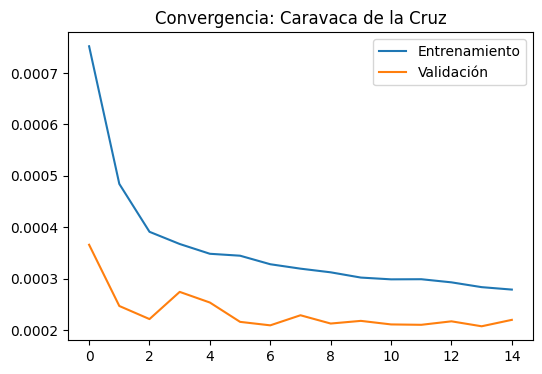

✅ Guardado: modelo_Caravaca_de_la_Cruz.keras

--- Iniciando modelo: Cartagena ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 8.6818e-04 - val_loss: 5.3448e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 4.7241e-04 - val_loss: 2.7287e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 3.3338e-04 - val_loss: 3.2187e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.2474e-04 - val_loss: 2.0106e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 2.8586e-04 - val_loss: 1.7933e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 2.7959e-04 - val_loss: 1.9250e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 2.9272e-04 - val_loss: 1.8316e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 2.6807e-04 - val_loss: 1.9399e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.7303e-04 - val_loss: 1.8717e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step 

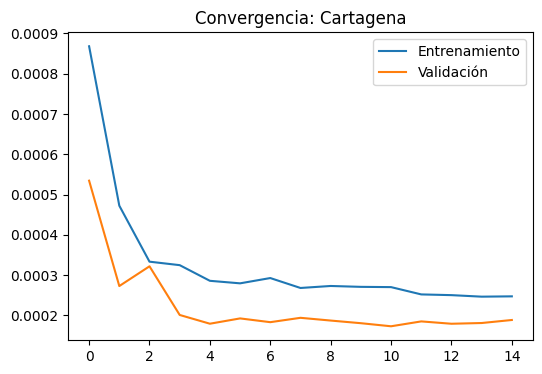

✅ Guardado: modelo_Cartagena.keras

--- Iniciando modelo: Cieza ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 7.4368e-04 - val_loss: 5.3628e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 4.7678e-04 - val_loss: 2.5541e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 4.0674e-04 - val_loss: 2.5062e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.6733e-04 - val_loss: 2.1813e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.6115e-04 - val_loss: 2.2371e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 3.4182e-04 - val_loss: 2.3385e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 3.3352e-04 - val_loss: 2.1354e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 3.2855e-04 - val_loss: 2.1990e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 3.1911e-04 - val_loss: 2.1060e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.1000e

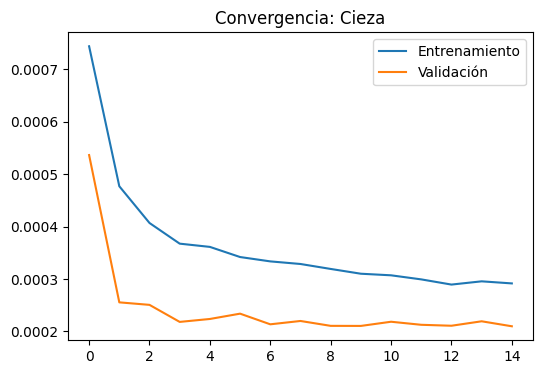

✅ Guardado: modelo_Cieza.keras

--- Iniciando modelo: Jumilla ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 7.6766e-04 - val_loss: 4.7060e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 5.0550e-04 - val_loss: 2.6560e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 4.0998e-04 - val_loss: 2.3260e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 3.7404e-04 - val_loss: 2.3769e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 3.4487e-04 - val_loss: 2.3206e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.5220e-04 - val_loss: 2.1950e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 3.4385e-04 - val_loss: 2.0897e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 3.2310e-04 - val_loss: 2.0721e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 3.1230e-04 - val_loss: 2.1610e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 2.9958e

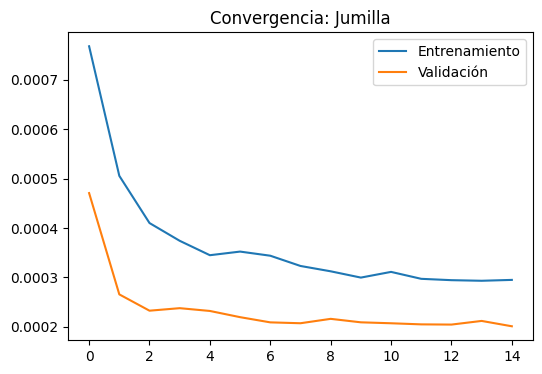

✅ Guardado: modelo_Jumilla.keras

--- Iniciando modelo: Lorca ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 8.1834e-04 - val_loss: 5.9687e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 4.5297e-04 - val_loss: 4.5237e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 3.7589e-04 - val_loss: 3.2255e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 3.4094e-04 - val_loss: 3.3322e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 3.2061e-04 - val_loss: 3.2607e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.2623e-04 - val_loss: 3.5213e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 3.1355e-04 - val_loss: 3.2018e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 3.1504e-04 - val_loss: 3.7445e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.1320e-04 - val_loss: 3.2279e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 3.1029e-

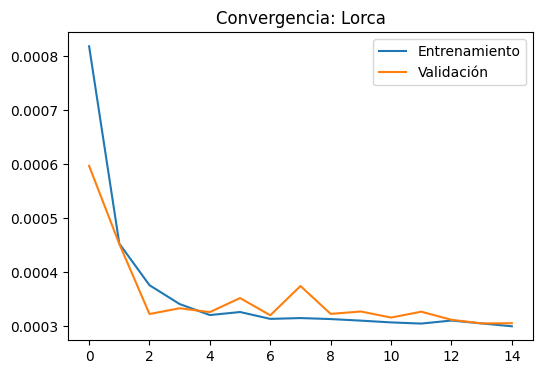

✅ Guardado: modelo_Lorca.keras

--- Iniciando modelo: Mazarrón ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 8.3737e-04 - val_loss: 5.2541e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 4.8706e-04 - val_loss: 4.0464e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 3.7545e-04 - val_loss: 3.2897e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 3.5414e-04 - val_loss: 3.3179e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 3.3000e-04 - val_loss: 3.2215e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 3.3325e-04 - val_loss: 3.2636e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 3.2074e-04 - val_loss: 3.1002e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 3.2504e-04 - val_loss: 3.1018e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 3.1820e-04 - val_loss: 3.3559e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 3.0713

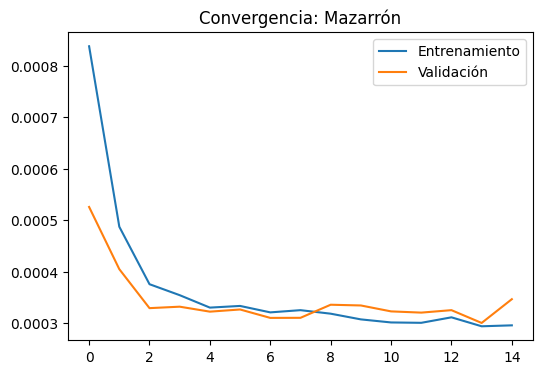

✅ Guardado: modelo_Mazarrón.keras

--- Iniciando modelo: Molina de Segura ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 7.3163e-04 - val_loss: 3.7521e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 4.8229e-04 - val_loss: 2.5508e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 3.9695e-04 - val_loss: 2.2233e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 3.5562e-04 - val_loss: 2.3025e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.5563e-04 - val_loss: 2.2475e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 3.3385e-04 - val_loss: 2.5216e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 3.2684e-04 - val_loss: 2.1795e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 3.1736e-04 - val_loss: 2.0861e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 3.2012e-04 - val_loss: 2.1072e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - l

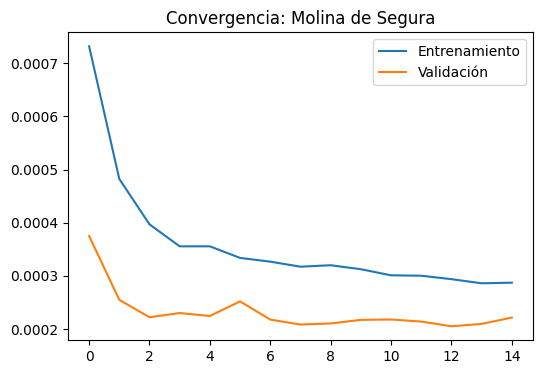

✅ Guardado: modelo_Molina_de_Segura.keras

--- Iniciando modelo: Murcia Capital ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 7.6321e-04 - val_loss: 3.6027e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5.1224e-04 - val_loss: 2.9447e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 4.0936e-04 - val_loss: 2.7892e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 3.7602e-04 - val_loss: 2.1790e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 3.4867e-04 - val_loss: 2.2202e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.2761e-04 - val_loss: 2.2467e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 3.2921e-04 - val_loss: 2.1340e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 3.1723e-04 - val_loss: 2.2840e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 3.1415e-04 - val_loss: 2.1351e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/st

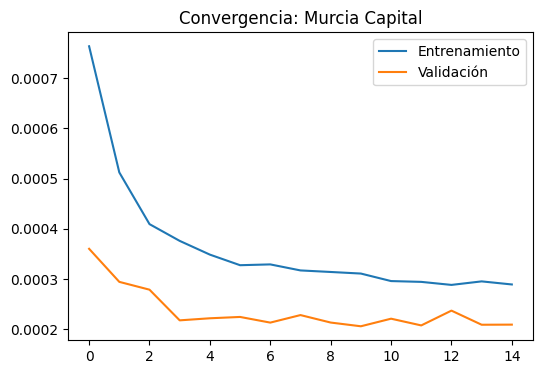

✅ Guardado: modelo_Murcia_Capital.keras

--- Iniciando modelo: San Javier ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 8.1187e-04 - val_loss: 3.6733e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 4.5482e-04 - val_loss: 3.1383e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 3.5463e-04 - val_loss: 2.2104e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.0711e-04 - val_loss: 1.9669e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 2.9067e-04 - val_loss: 1.9563e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 2.7300e-04 - val_loss: 1.8208e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.7278e-04 - val_loss: 1.7757e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 2.6692e-04 - val_loss: 1.8195e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.6695e-04 - val_loss: 1.7944e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - l

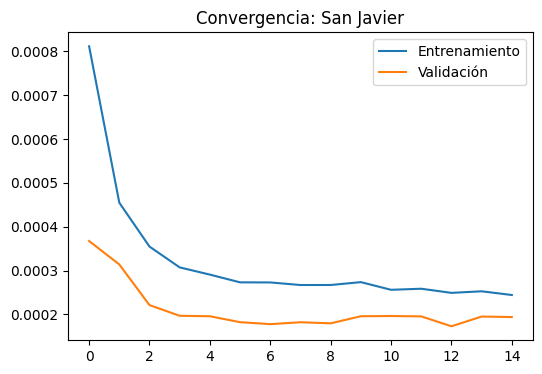

✅ Guardado: modelo_San_Javier.keras

--- Iniciando modelo: Torre-Pacheco ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 7.4376e-04 - val_loss: 3.4745e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 4.3123e-04 - val_loss: 2.6777e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 3.3371e-04 - val_loss: 2.2210e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.0404e-04 - val_loss: 2.0083e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 2.7497e-04 - val_loss: 1.9802e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.6098e-04 - val_loss: 1.9356e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 2.6451e-04 - val_loss: 1.8741e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 2.6923e-04 - val_loss: 1.9996e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 2.5584e-04 - val_loss: 2.2837e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - lo

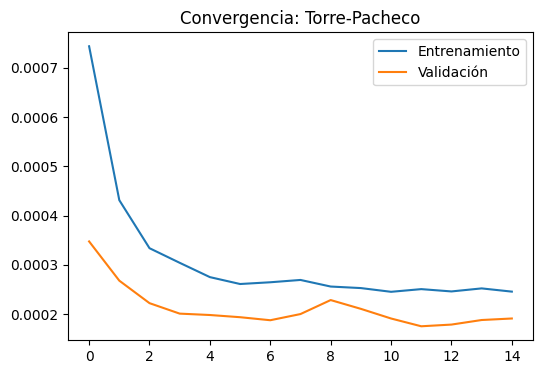

✅ Guardado: modelo_Torre-Pacheco.keras

--- Iniciando modelo: Totana ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 7.3819e-04 - val_loss: 5.4113e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 4.5272e-04 - val_loss: 3.8467e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.6393e-04 - val_loss: 3.3041e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 3.4748e-04 - val_loss: 3.2953e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 3.2615e-04 - val_loss: 3.1876e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 3.3138e-04 - val_loss: 3.1457e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 3.1870e-04 - val_loss: 3.0532e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 3.2055e-04 - val_loss: 3.1176e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 3.1074e-04 - val_loss: 3.2541e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 

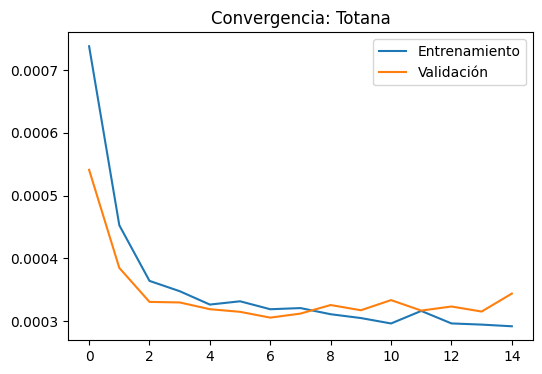

✅ Guardado: modelo_Totana.keras

--- Iniciando modelo: Yecla ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0020 - val_loss: 9.8260e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0011 - val_loss: 7.8239e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 9.5872e-04 - val_loss: 7.2163e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 9.2052e-04 - val_loss: 7.9158e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9.1316e-04 - val_loss: 8.4046e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.7391e-04 - val_loss: 7.2398e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 8.7252e-04 - val_loss: 6.9620e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 8.7758e-04 - val_loss: 7.1794e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 8.4586e-04 - val_loss: 7.0187e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 8.2736e-04 - val

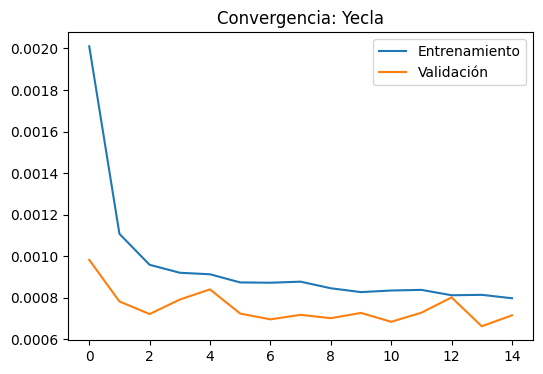

✅ Guardado: modelo_Yecla.keras

--- Iniciando modelo: Águilas ---
Epoch 1/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 7.9906e-04 - val_loss: 6.2067e-04
Epoch 2/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 4.7646e-04 - val_loss: 3.7810e-04
Epoch 3/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.7051e-04 - val_loss: 3.6300e-04
Epoch 4/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 3.5006e-04 - val_loss: 3.6635e-04
Epoch 5/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 3.2828e-04 - val_loss: 3.6972e-04
Epoch 6/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.3146e-04 - val_loss: 3.1354e-04
Epoch 7/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 3.2480e-04 - val_loss: 3.0651e-04
Epoch 8/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.2303e-04 - val_loss: 3.0983e-04
Epoch 9/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 3.1176e-04 - val_loss: 3.0961e-04
Epoch 10/15
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.1273e

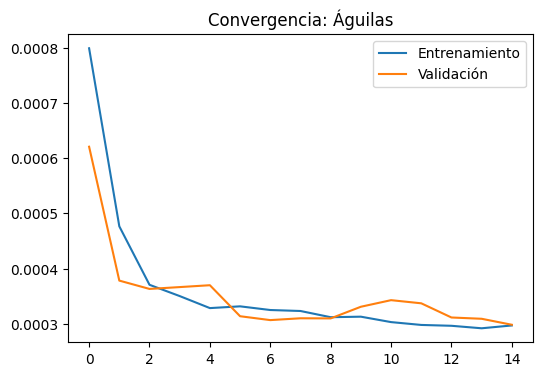

✅ Guardado: modelo_Águilas.keras

--- Iniciando modelo: GLOBAL ---
Epoch 1/15
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 196s 15ms/step - loss: 3.3138e-04 - val_loss: 2.1033e-04
Epoch 2/15
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 192s 15ms/step - loss: 2.6244e-04 - val_loss: 2.1906e-04
Epoch 3/15
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 183s 15ms/step - loss: 2.4687e-04 - val_loss: 2.1829e-04
Epoch 4/15
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 185s 15ms/step - loss: 2.3483e-04 - val_loss: 1.9207e-04
Epoch 5/15
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 192s 16ms/step - loss: 2.2798e-04 - val_loss: 1.9537e-04
Epoch 6/15
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 187s 15ms/step - loss: 2.2014e-04 - val_loss: 1.9265e-04
Epoch 7/15
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 179s 15ms/step - loss: 2.1471e-04 - val_loss: 1.8688e-04
Epoch 8/15
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 177s 14ms/step - loss: 2.0925e-04 - val_loss: 1.9979e-04
Epoch 9/15
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 184s 15ms/step - loss: 2.0355e-04 - val_loss: 2.0012e-04
Epoch 10/15
12329/12329 

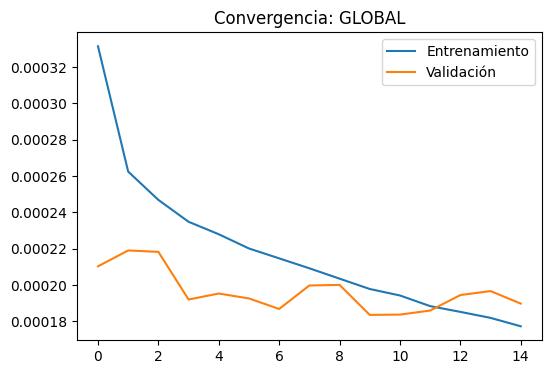

✅ Guardado: modelo_GLOBAL.keras

🎉 Todos los modelos finalizados correctamente.


In [13]:
#@title 2. Ejecución del Entrenamiento Masivo (LSTM por Estación) { display-mode: "form" }

def create_sequences(data, seq_length=8):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, 0]) # PM10 es nuestro objetivo (índice 0)
    return np.array(x), np.array(y)

estaciones = list(df['Estacion'].unique()) + ['GLOBAL']

for est in estaciones:
    print(f"\n--- Iniciando modelo: {est} ---")

    # Selección de datos
    subset = df if est == 'GLOBAL' else df[df['Estacion'] == est]
    subset = subset[features].fillna(0)

    # Preprocesamiento
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(subset.values)
    X, y = create_sequences(data_scaled)

    # Modelo LSTM Dinámico
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(8, len(features))),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    # Entrenamiento
    history = model.fit(X, y, epochs=15, batch_size=32, validation_split=0.1, verbose=1)

    # Gráfica de convergencia (Loss)
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f"Convergencia: {est}")
    plt.legend()
    plt.show()

    # Guardar modelo
    model.save(os.path.join(RUTA_OUTPUT, f"modelo_{est.replace(' ', '_')}.keras"))
    print(f"✅ Guardado: modelo_{est.replace(' ', '_')}.keras")

print("\n🎉 Todos los modelos finalizados correctamente.")